In [1]:
# %matplotlib ipympl

In [22]:
from pathlib import Path

import neurokit2 as nk
import numpy as np
import pandas as pd
import scipy.io
import scipy.signal
from matplotlib import pyplot as plt
from tqdm import tqdm

In [23]:
data_dir = Path('data')

In [24]:
csv_dir = data_dir / 'csvs'

In [28]:
ppg_dir = data_dir / 'ppg'

In [25]:
subjects_path = csv_dir / 'subjects.csv'

In [29]:
df_subjects = pd.read_csv(subjects_path)

In [30]:
df_subjects['patient_file'] = df_subjects.apply(lambda r: ppg_dir / f'p{r["subject_id"]:06d}_{r["segment_id"]}.mat', axis=1)

In [31]:
subject_id, category, patient_file = df_subjects.loc[0, ['subject_id', 'class', 'patient_file']]

In [32]:
fs = 125

In [33]:
mat = scipy.io.loadmat(patient_file)

In [34]:
t = mat['time'].squeeze()
ppg_raw = mat['data'].squeeze()

In [35]:
ppg_none = nk.ppg.ppg_clean(ppg_signal=ppg_raw, sampling_rate=fs, method="none")

(0.0, 10.0)

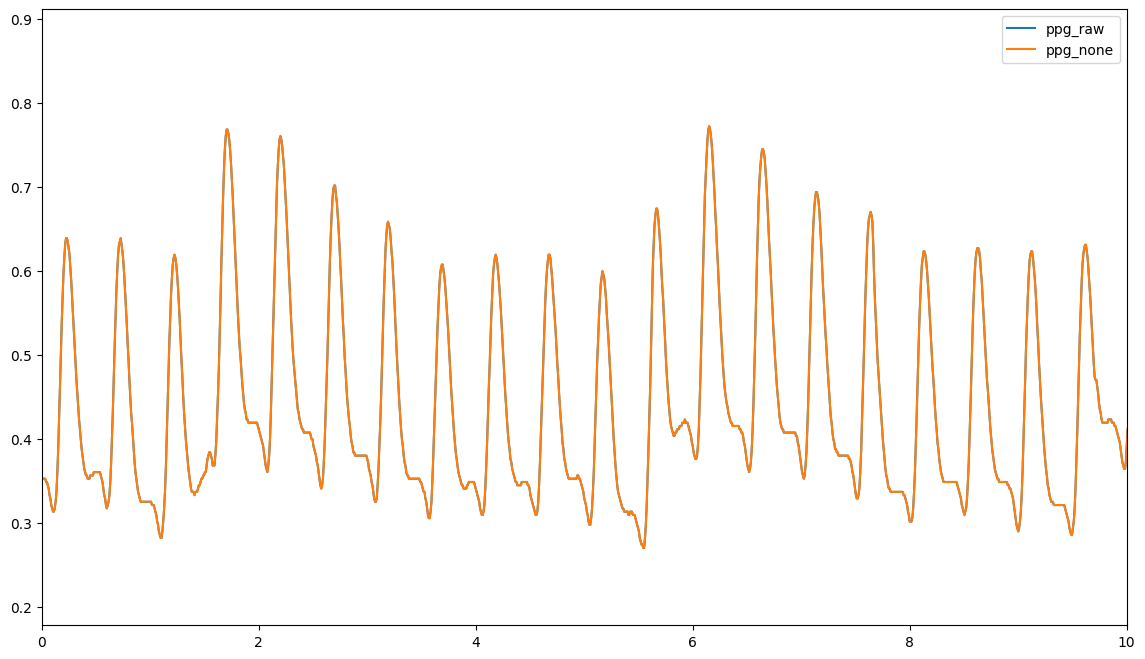

In [36]:
fig, axes = plt.subplots(figsize=(14, 8))
plt.plot(t, ppg_raw, t, ppg_none)
plt.legend(['ppg_raw', 'ppg_none'])
plt.xlim(0, 10)

In [11]:
ppg_elgendi = nk.ppg.ppg_clean(ppg_signal=ppg_raw, sampling_rate=fs)

(0.0, 10.0)

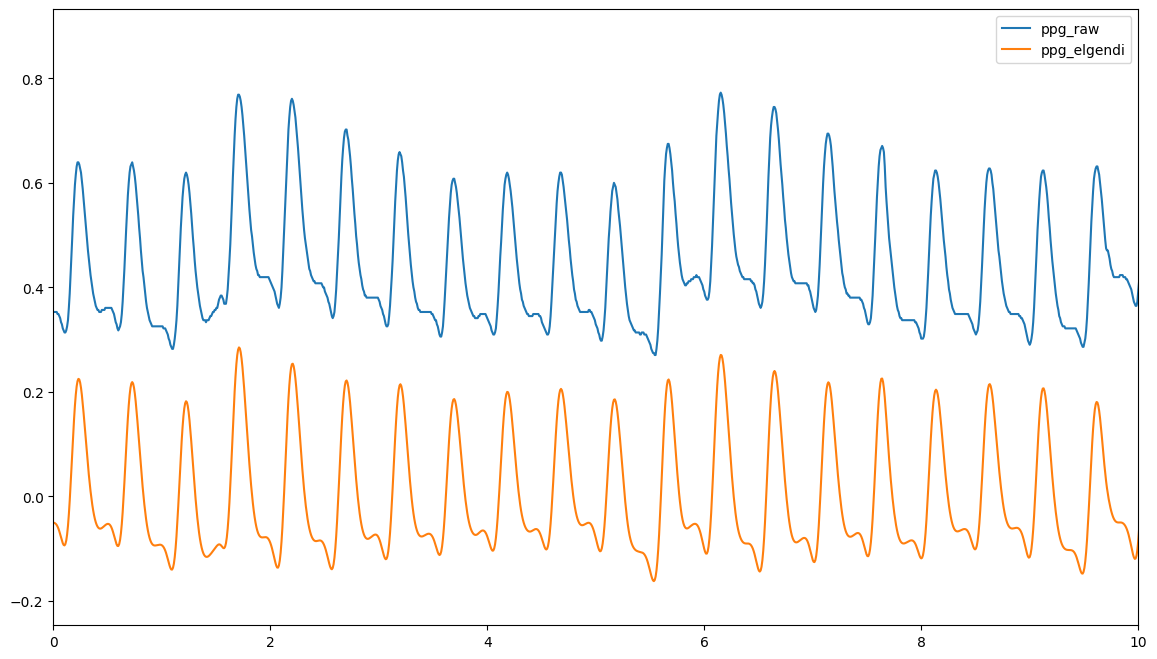

In [12]:
fig, axes = plt.subplots(figsize=(14, 8))
plt.plot(t, ppg_raw, t, ppg_elgendi)
plt.legend(['ppg_raw', 'ppg_elgendi'])
plt.xlim(0, 10)

In [13]:
b, a = scipy.signal.cheby2(4, 20, 30, fs=fs)
ppg_filt = scipy.signal.filtfilt(b, a, ppg_raw)

(0.0, 10.0)

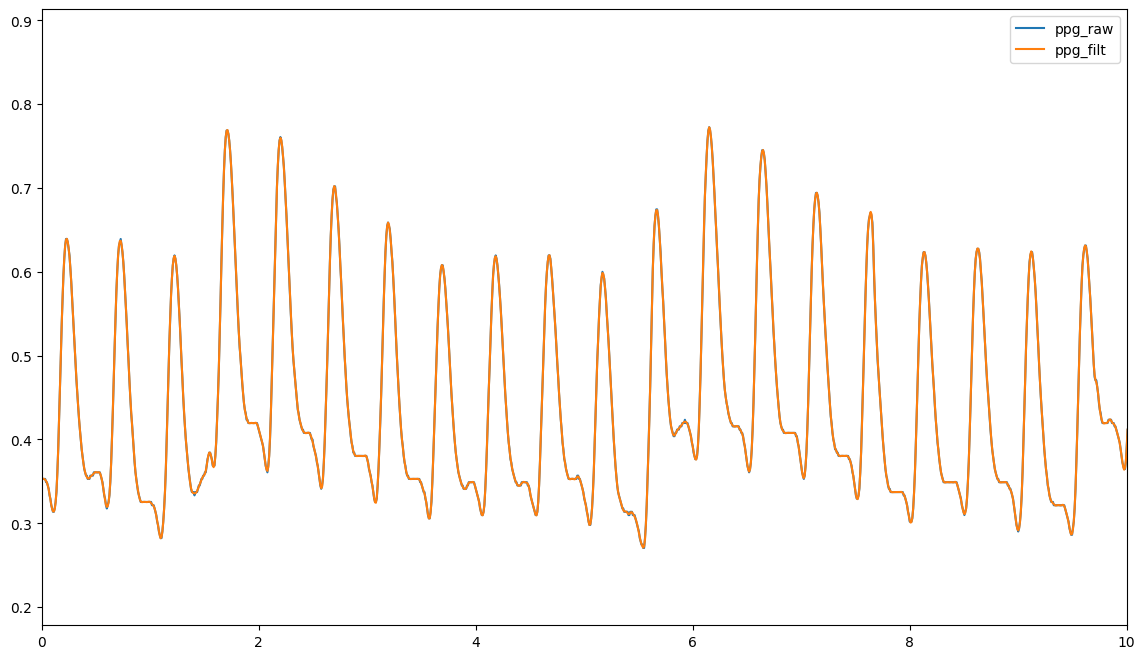

In [14]:
fig, axes = plt.subplots(figsize=(14, 8))
plt.plot(t, ppg_raw, t, ppg_filt)
plt.legend(['ppg_raw', 'ppg_filt'])
plt.xlim(0, 10)

In [15]:
ppg_points = nk.ppg.ppg_peaks(ppg_cleaned=ppg_filt, sampling_rate=fs)
ppg_points

(       PPG_Peaks
 0              0
 1              0
 2              0
 3              0
 4              0
 ...          ...
 37495          0
 37496          0
 37497          0
 37498          0
 37499          0
 
 [37500 rows x 1 columns],
 {'method_peaks': 'elgendi',
  'method_fixpeaks': 'None',
  'PPG_Peaks': array([   91,   153,   214,   275,   337,   399,   461,   523,   585,
           646,   709,   769,   831,   893,   955,  1017,  1078,  1140,
          1202,  1263,  1324,  1387,  1449,  1510,  1573,  1634,  1696,
          1757,  1819,  1882,  1944,  2006,  2067,  2129,  2190,  2251,
          2313,  2374,  2436,  2495,  2558,  2620,  2680,  2741,  2802,
          2863,  2924,  2985,  3046,  3106,  3167,  3228,  3289,  3350,
          3411,  3471,  3532,  3591,  3649,  3710,  3769,  3832,  3893,
          3954,  4015,  4076,  4137,  4198,  4259,  4320,  4382,  4443,
          4504,  4565,  4627,  4689,  4750,  4812,  4873,  4935,  4997,
          5058,  5120,  5181,  5243,

(0.0, 60.0)

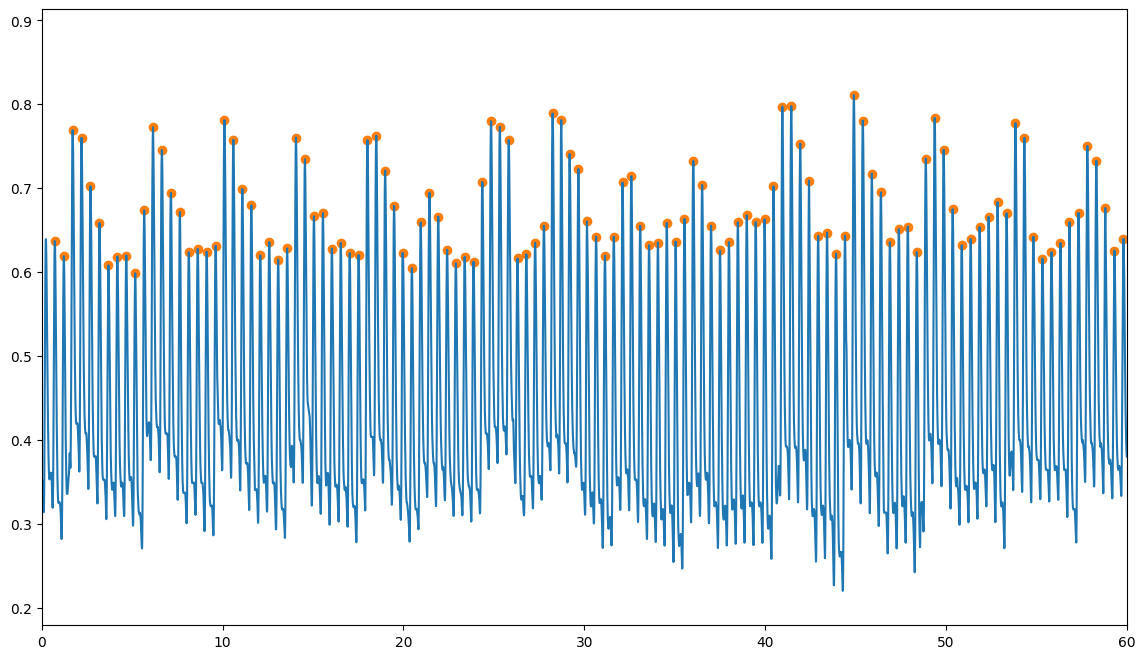

In [16]:
fig, axes = plt.subplots(figsize=(14, 8))
plt.plot(t, ppg_filt, color='C0')
plt.scatter(t[ppg_points[1]['PPG_Peaks']], ppg_filt[ppg_points[1]['PPG_Peaks']], color='C1')
# plt.legend(['ppg_filt'])
plt.xlim(0, 60)

In [17]:
ppg_points = nk.ppg.ppg_peaks(ppg_cleaned=ppg_filt, sampling_rate=fs, method="charlton")
ppg_points

(       PPG_Peaks
 0              0
 1              0
 2              0
 3              0
 4              0
 ...          ...
 37495          0
 37496          0
 37497          0
 37498          0
 37499          0
 
 [37500 rows x 1 columns],
 {'method_peaks': 'charlton',
  'method_fixpeaks': 'Charlton2022',
  'PPG_Peaks': array([   91,   153,   214,   275,   337,   399,   461,   523,   585,
           646,   709,   769,   831,   893,   955,  1017,  1078,  1140,
          1202,  1263,  1324,  1387,  1449,  1510,  1573,  1634,  1696,
          1757,  1819,  1882,  1944,  2006,  2067,  2129,  2190,  2251,
          2313,  2374,  2436,  2495,  2558,  2620,  2680,  2741,  2802,
          2863,  2924,  2985,  3046,  3106,  3167,  3228,  3289,  3350,
          3411,  3471,  3532,  3591,  3649,  3710,  3769,  3832,  3893,
          3954,  4015,  4076,  4137,  4198,  4259,  4320,  4382,  4443,
          4504,  4565,  4627,  4689,  4750,  4812,  4873,  4935,  4997,
          5058,  5120,  518

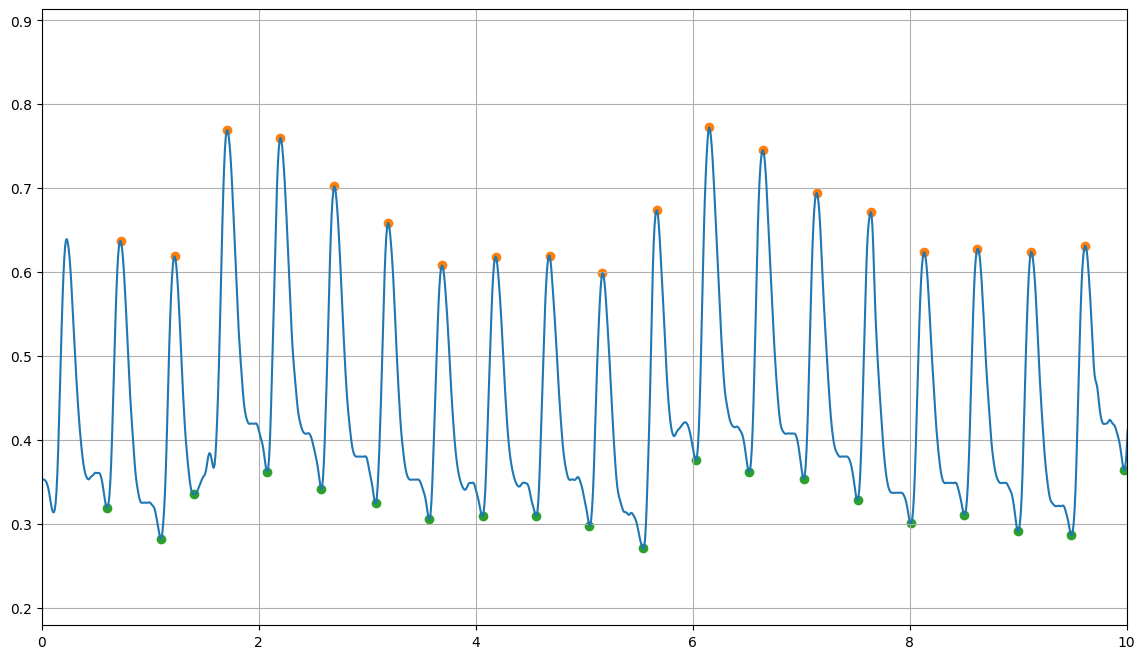

In [18]:
fig, axes = plt.subplots(figsize=(14, 8))
plt.plot(t, ppg_filt, color='C0')
plt.scatter(t[ppg_points[1]['PPG_Peaks']], ppg_filt[ppg_points[1]['PPG_Peaks']], color='C1')
plt.scatter(t[ppg_points[1]['PPG_Onsets']], ppg_filt[ppg_points[1]['PPG_Onsets']], color='C2')
# plt.scatter(t[ppg_points[1]['PPG_Peaks_Unfixed']], ppg_filt[ppg_points[1]['PPG_Peaks_Unfixed']], color='C3')
# plt.scatter(t[ppg_points[1]['PPG_Onsets_Unfixed']], ppg_filt[ppg_points[1]['PPG_Onsets_Unfixed']], color='C4')
# plt.legend(['ppg_filt'])
plt.xlim(0, 10)
plt.grid()

In [19]:
vpg = np.gradient(ppg_filt, t)

In [20]:
ppg_points2 = nk.ppg.ppg_peaks(ppg_cleaned=vpg, sampling_rate=fs, method="charlton")
ppg_points2

(       PPG_Peaks
 0              0
 1              0
 2              0
 3              0
 4              0
 ...          ...
 37495          0
 37496          0
 37497          0
 37498          0
 37499          0
 
 [37500 rows x 1 columns],
 {'method_peaks': 'charlton',
  'method_fixpeaks': 'Charlton2022',
  'PPG_Peaks': array([   83,   145,   206,   268,   330,   393,   453,   514,   576,
           638,   702,   761,   823,   885,   947,  1009,  1071,  1132,
          1194,  1255,  1317,  1380,  1442,  1504,  1566,  1628,  1689,
          1748,  1810,  1873,  1935,  1997,  2059,  2121,  2182,  2243,
          2305,  2366,  2428,  2490,  2551,  2613,  2671,  2732,  2794,
          2855,  2915,  2977,  3038,  3098,  3157,  3219,  3280,  3342,
          3403,  3463,  3524,  3585,  3640,  3701,  3763,  3824,  3886,
          3946,  4007,  4068,  4130,  4192,  4251,  4312,  4374,  4435,
          4496,  4557,  4619,  4682,  4743,  4805,  4866,  4928,  4990,
          5050,  5111,  517

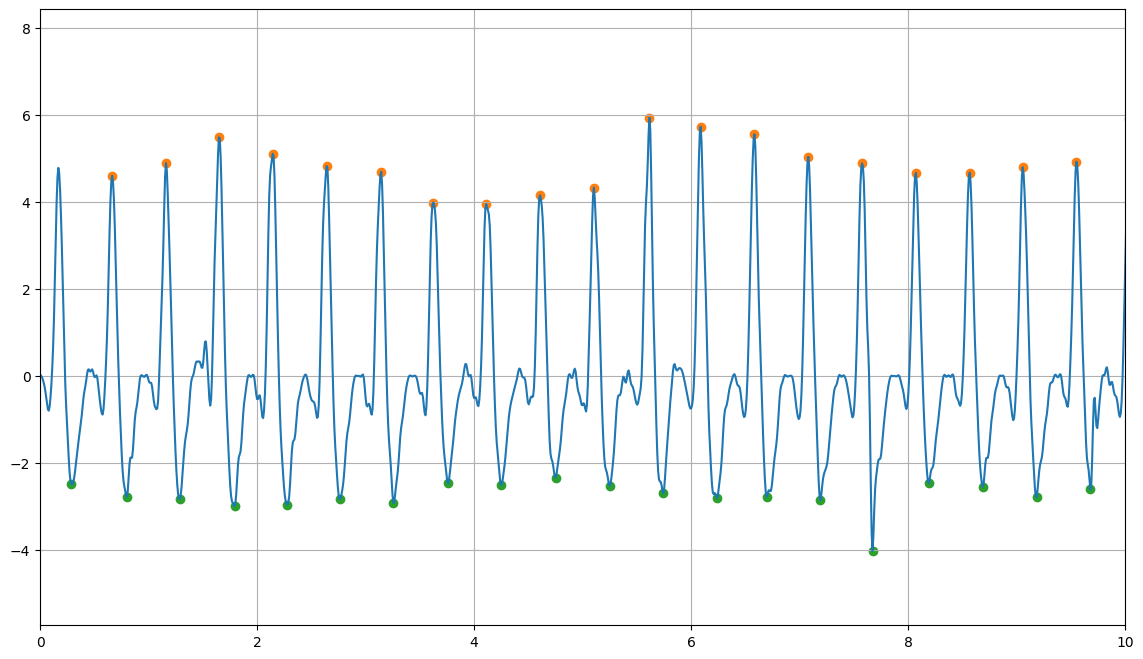

In [21]:
fig, axes = plt.subplots(figsize=(14, 8))
plt.plot(t, vpg, color='C0')
plt.scatter(t[ppg_points2[1]['PPG_Peaks']], vpg[ppg_points2[1]['PPG_Peaks']], color='C1')
plt.scatter(t[ppg_points2[1]['PPG_Onsets']], vpg[ppg_points2[1]['PPG_Onsets']], color='C2')
# plt.scatter(t[ppg_points[1]['PPG_Peaks_Unfixed']], ppg_filt[ppg_points[1]['PPG_Peaks_Unfixed']], color='C3')
# plt.scatter(t[ppg_points[1]['PPG_Onsets_Unfixed']], ppg_filt[ppg_points[1]['PPG_Onsets_Unfixed']], color='C4')
# plt.legend(['ppg_filt'])
plt.xlim(0, 10)
plt.grid()